# Data Science Job Salaries — Exploratory Data Analysis

**Dataset**: [ruchi798/data-science-job-salaries](https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries)

**Goal**: Understand the structure, distributions, and salary landscape before making any feature or modelling decisions.

Each column is described — labels, types, and meaning — at the point where it is explored.


## 1 · Import Required Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")
print(f"seaborn {sns.__version__}")

pandas  3.0.2
numpy   2.4.4
seaborn 0.13.2


## 2 · Load and Preview the Dataset

In [3]:
DATA_PATH = "../data/raw/ds_salaries.csv"

df = pd.read_csv(DATA_PATH)

# Drop auto-generated index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(f"Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(10)

Shape : 607 rows × 11 columns


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L
5,2020,EN,FT,Data Analyst,72000,USD,72000,US,100,US,L
6,2020,SE,FT,Lead Data Scientist,190000,USD,190000,US,100,US,S
7,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L
8,2020,MI,FT,Business Data Analyst,135000,USD,135000,US,100,US,L
9,2020,SE,FT,Lead Data Engineer,125000,USD,125000,NZ,50,NZ,S


In [4]:
# Data types
df.dtypes.to_frame(name="dtype")

,dtype
work_year,int64
experience_level,str
employment_type,str
job_title,str
salary,int64
salary_currency,str
salary_in_usd,int64
employee_residence,str
remote_ratio,int64
company_location,str


In [5]:
# Missing values
missing = df.isnull().sum().to_frame(name="missing")
missing["pct"] = (missing["missing"] / len(df) * 100).round(2) # this will give us the percentage of missing values in each column
missing

,missing,pct
work_year,0,0.0
experience_level,0,0.0
employment_type,0,0.0
job_title,0,0.0
salary,0,0.0
salary_currency,0,0.0
salary_in_usd,0,0.0
employee_residence,0,0.0
remote_ratio,0,0.0
company_location,0,0.0


In [6]:
# Statistical summary — numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
work_year,607.0,2021.405272,6.921330e-01,2020.0,2021.0,2022.0,2022.0,2022.0
salary,607.0,324000.062603,1.544357e+06,4000.0,70000.0,115000.0,165000.0,30400000.0
salary_in_usd,607.0,112297.869852,7.095726e+04,2859.0,62726.0,101570.0,150000.0,600000.0
remote_ratio,607.0,70.922570,4.070913e+01,0.0,50.0,100.0,100.0,100.0


## 3 · Explore the Columns

For each column: unique value count, distinct values (or top-10 for high-cardinality columns), and missing count.

In [7]:
for col in df.columns:
    n_unique = df[col].nunique()
    n_missing = df[col].isnull().sum()
    pct_missing = n_missing / len(df) * 100

    if n_unique <= 20:
        observed = df[col].value_counts().to_dict()
    else:
        top = df[col].value_counts().head(10).to_dict()
        observed = f"(top 10 of {n_unique}) {top}"

    print(f"\n{'═'*60}")
    print(f"  Column      : {col}")
    print(f"  Unique vals : {n_unique}")
    print(f"  Missing     : {n_missing} ({pct_missing:.1f}%)")
    print(f"  Observed    : {observed}")



════════════════════════════════════════════════════════════
  Column      : work_year
  Unique vals : 3
  Missing     : 0 (0.0%)
  Observed    : {2022: 318, 2021: 217, 2020: 72}

════════════════════════════════════════════════════════════
  Column      : experience_level
  Unique vals : 4
  Missing     : 0 (0.0%)
  Observed    : {'SE': 280, 'MI': 213, 'EN': 88, 'EX': 26}

════════════════════════════════════════════════════════════
  Column      : employment_type
  Unique vals : 4
  Missing     : 0 (0.0%)
  Observed    : {'FT': 588, 'PT': 10, 'CT': 5, 'FL': 4}

════════════════════════════════════════════════════════════
  Column      : job_title
  Unique vals : 50
  Missing     : 0 (0.0%)
  Observed    : (top 10 of 50) {'Data Scientist': 143, 'Data Engineer': 132, 'Data Analyst': 97, 'Machine Learning Engineer': 41, 'Research Scientist': 16, 'Data Science Manager': 12, 'Data Architect': 11, 'Machine Learning Scientist': 8, 'Big Data Engineer': 8, 'Data Science Consultant': 7}

════

## 4 · Analyze Value Distributions


### `experience_level`

| Code | Label |
|------|-------|
| `EN` | Entry-level / Junior |
| `MI` | Mid-level / Intermediate |
| `SE` | Senior-level / Expert |
| `EX` | Executive-level / Director |


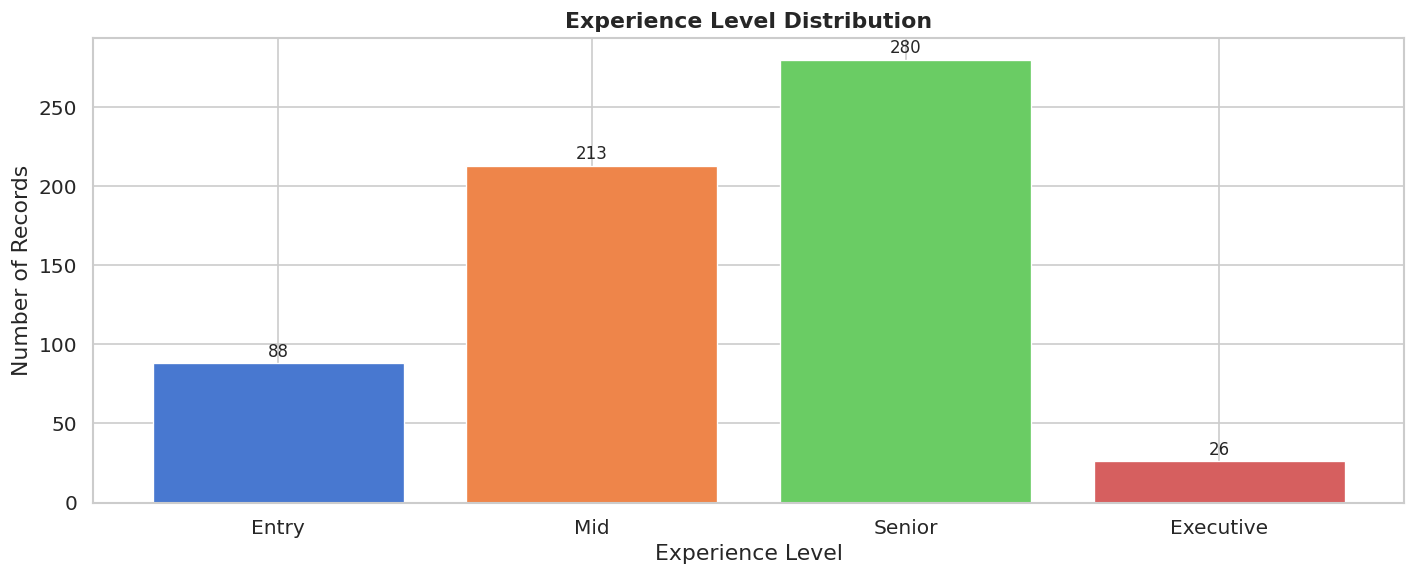

In [8]:
# ── Experience Level ──────────────────────────────────────────────────
exp_labels = {"EN": "Entry", "MI": "Mid", "SE": "Senior", "EX": "Executive"}
exp_order = ["EN", "MI", "SE", "EX"]

fig, ax = plt.subplots()
counts = df["experience_level"].value_counts().reindex(exp_order)
bars = ax.bar(
    [exp_labels[k] for k in exp_order],
    counts.values,
    color=sns.color_palette("muted", 4),
    edgecolor="white",
    linewidth=0.8,
)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, str(val),
            ha="center", va="bottom", fontsize=10)
ax.set_title("Experience Level Distribution", fontweight="bold")
ax.set_xlabel("Experience Level")
ax.set_ylabel("Number of Records")
plt.tight_layout()
plt.show()

### `employment_type` 

| Code | Label |
|------|-------|
| `FT` | Full-time |
| `PT` | Part-time |
| `CT` | Contract |
| `FL` | Freelance |


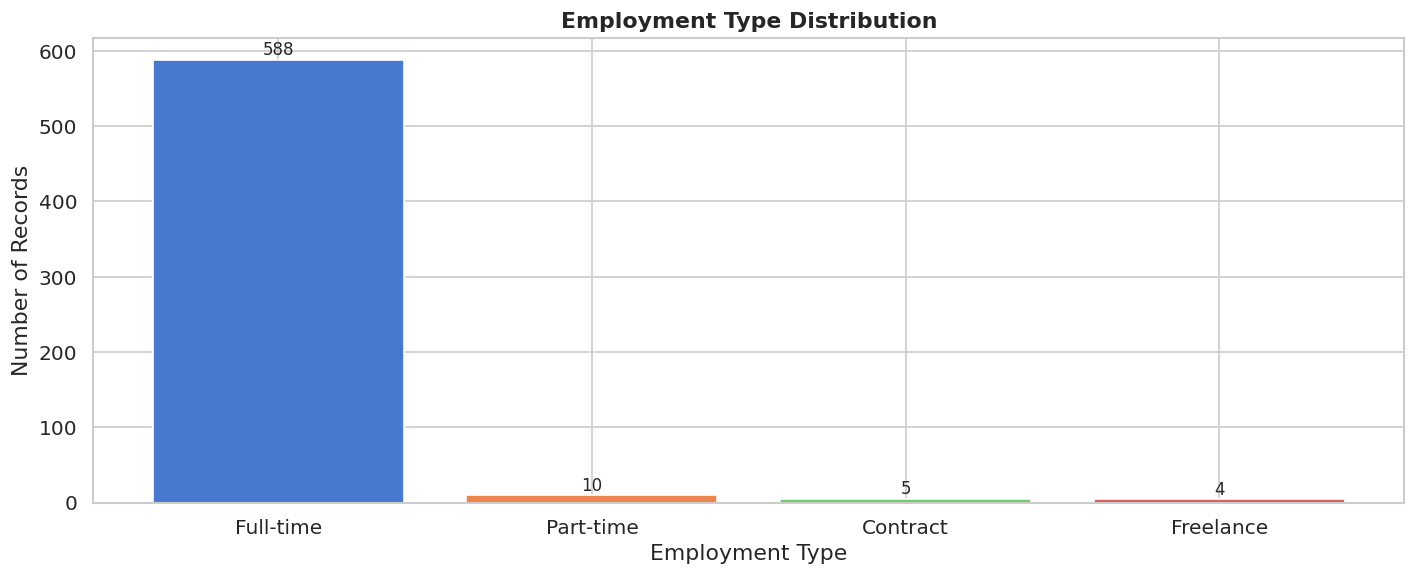

In [9]:
# ── Employment Type ───────────────────────────────────────────────────
emp_labels = {"FT": "Full-time", "PT": "Part-time", "CT": "Contract", "FL": "Freelance"}
emp_order = ["FT", "PT", "CT", "FL"]

fig, ax = plt.subplots()
counts = df["employment_type"].value_counts().reindex(emp_order).dropna()
bars = ax.bar(
    [emp_labels[k] for k in counts.index],
    counts.values,
    color=sns.color_palette("muted", len(counts)),
    edgecolor="white",
)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, str(val),
            ha="center", va="bottom", fontsize=10)
ax.set_title("Employment Type Distribution", fontweight="bold")
ax.set_xlabel("Employment Type")
ax.set_ylabel("Number of Records")
plt.tight_layout()
plt.show()

### `job_title` 
> high-cardinality (many unique values)

Role name (e.g. "Data Scientist", "ML Engineer", "Data Analyst").  
The top 20 most frequent titles are shown below.


Unique job titles: 50


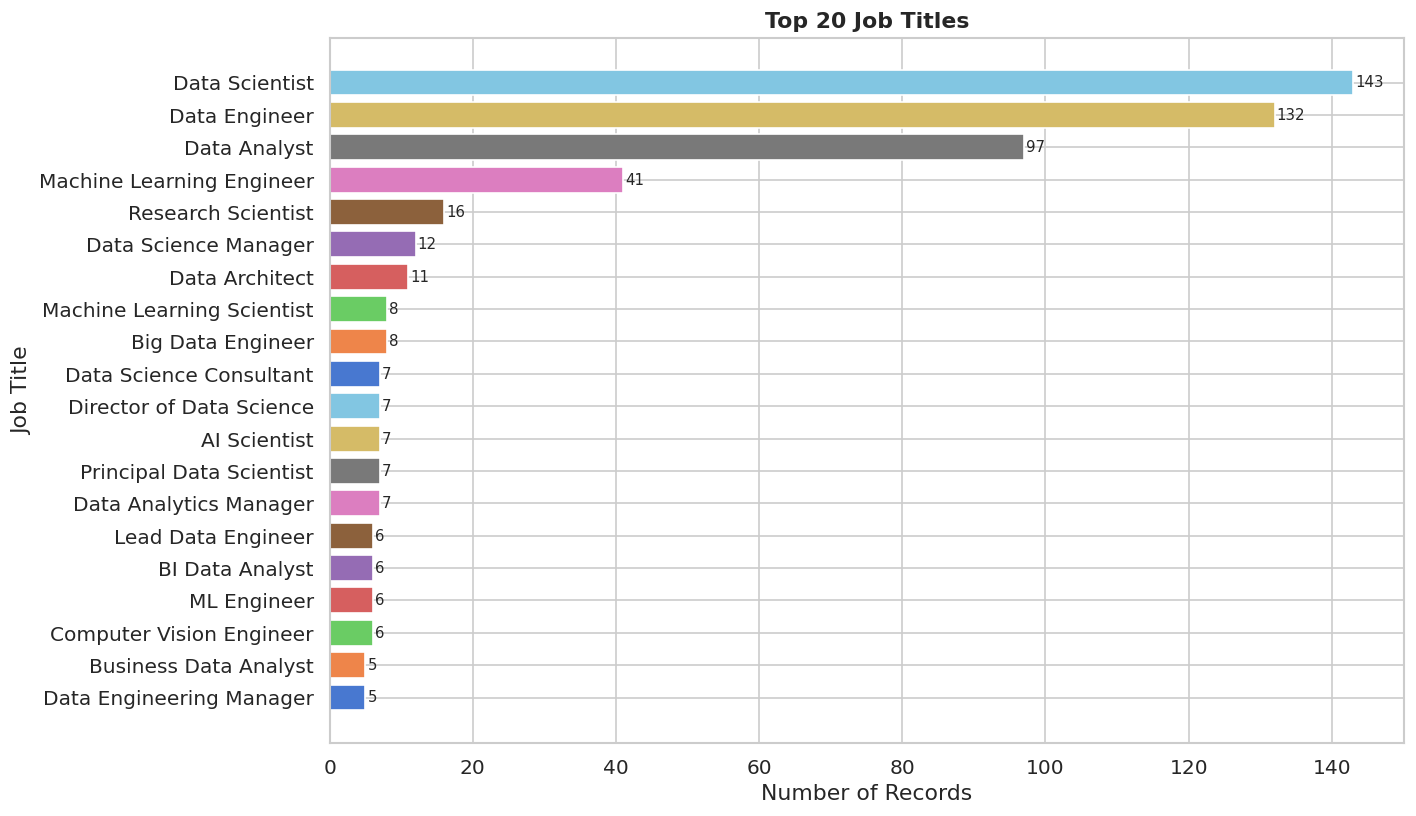

In [10]:
print(f"Unique job titles: {df['job_title'].nunique()}")

# ── Top 20 Job Titles ─────────────────────────────────────────────────
top_titles = df["job_title"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    top_titles.index[::-1], top_titles.values[::-1],
    color=sns.color_palette("muted", 20), edgecolor="white"
)
for bar, val in zip(bars, top_titles.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=9)
ax.set_title("Top 20 Job Titles", fontweight="bold")
ax.set_xlabel("Number of Records")
ax.set_ylabel("Job Title")
plt.tight_layout()
plt.show()

### `remote_ratio`

| Code | Label | 
|------|-------|
| `0` | On-site |
| `50` | Partially remote |
| `100` | Fully remote | 


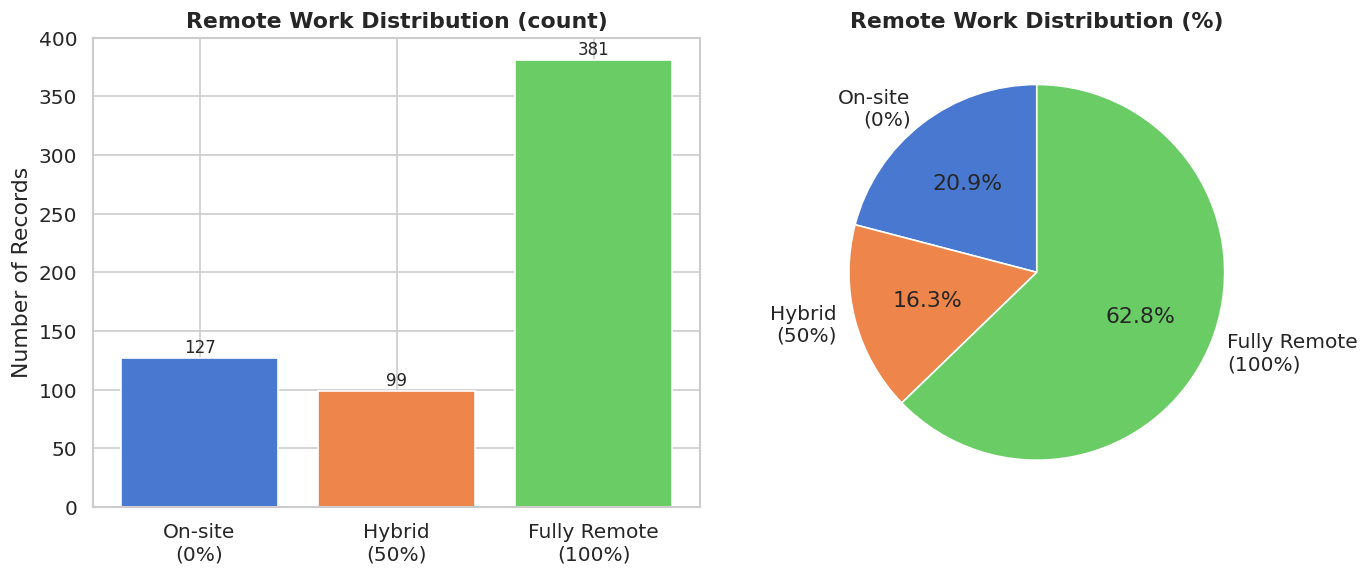

In [11]:
# ── Remote Ratio ──────────────────────────────────────────────────────
remote_labels = {0: "On-site\n(0%)", 50: "Hybrid\n(50%)", 100: "Fully Remote\n(100%)"}
remote_order = [0, 50, 100]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df["remote_ratio"].value_counts().reindex(remote_order).fillna(0).astype(int)

bars = axes[0].bar(
    [remote_labels[k] for k in remote_order], counts.values,
    color=sns.color_palette("muted", 3), edgecolor="white"
)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, str(val),
                 ha="center", va="bottom", fontsize=10)
axes[0].set_title("Remote Work Distribution (count)", fontweight="bold")
axes[0].set_ylabel("Number of Records")

axes[1].pie(
    counts.values, labels=[remote_labels[k] for k in remote_order],
    autopct="%1.1f%%", colors=sns.color_palette("muted", 3),
    startangle=90, wedgeprops={"edgecolor": "white"}
)
axes[1].set_title("Remote Work Distribution (%)", fontweight="bold")
plt.tight_layout()
plt.show()

### `company_size`

| Code | Label | Headcount |
|------|-------|-----------|
| `S` | Small | < 50 employees |
| `M` | Medium | 50 – 250 employees |
| `L` | Large | > 250 employees |


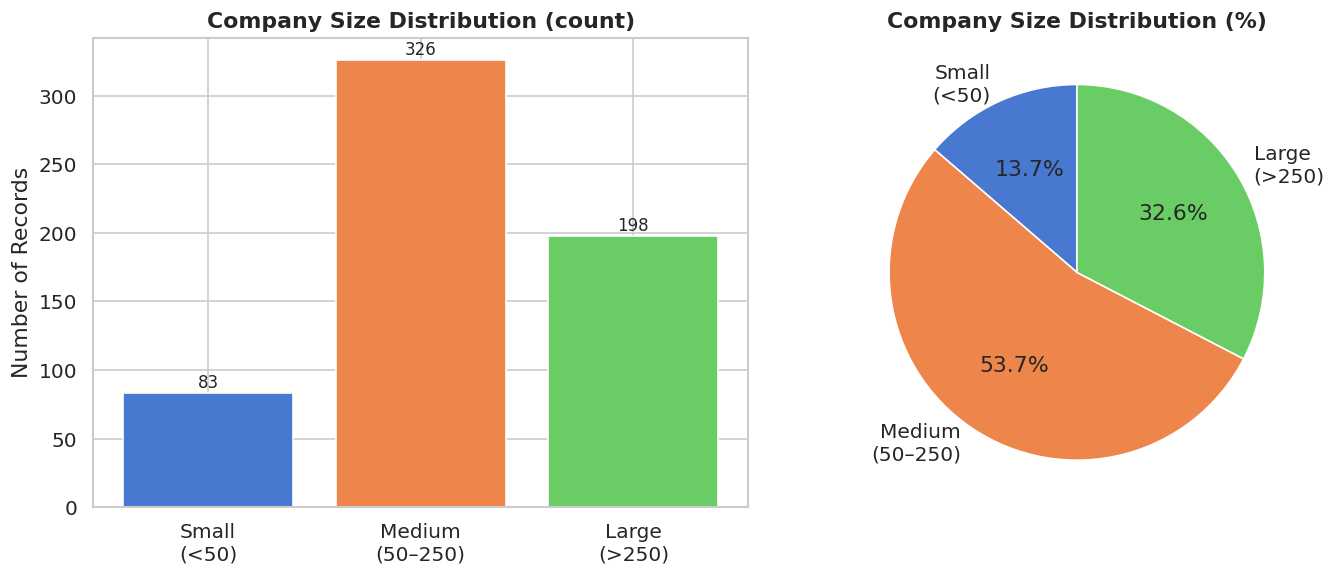

In [12]:
# ── Company Size ──────────────────────────────────────────────────────
size_labels = {"S": "Small\n(<50)", "M": "Medium\n(50–250)", "L": "Large\n(>250)"}
size_order = ["S", "M", "L"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df["company_size"].value_counts().reindex(size_order)

bars = axes[0].bar(
    [size_labels[k] for k in size_order], counts.values,
    color=sns.color_palette("muted", 3), edgecolor="white"
)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, str(val),
                 ha="center", va="bottom", fontsize=10)
axes[0].set_title("Company Size Distribution (count)", fontweight="bold")
axes[0].set_ylabel("Number of Records")

axes[1].pie(
    counts.values, labels=[size_labels[k] for k in size_order],
    autopct="%1.1f%%", colors=sns.color_palette("muted", 3),
    startangle=90, wedgeprops={"edgecolor": "white"}
)
axes[1].set_title("Company Size Distribution (%)", fontweight="bold")
plt.tight_layout()
plt.show()

### `work_year` · `employee_residence` · `company_location`

> These three columns are presented together as they share a similar scope — time and geography.

| Column | Type | Description |
|--------|------|-------------|
| `work_year` | integer | The year in which the salary was paid |
| `employee_residence` | categorical · nominal · high-cardinality | Employee's primary country of residence — ISO 3166 country code |
| `company_location` | categorical · nominal · high-cardinality | Country of the employer's main office or contracting branch — ISO 3166 country code |


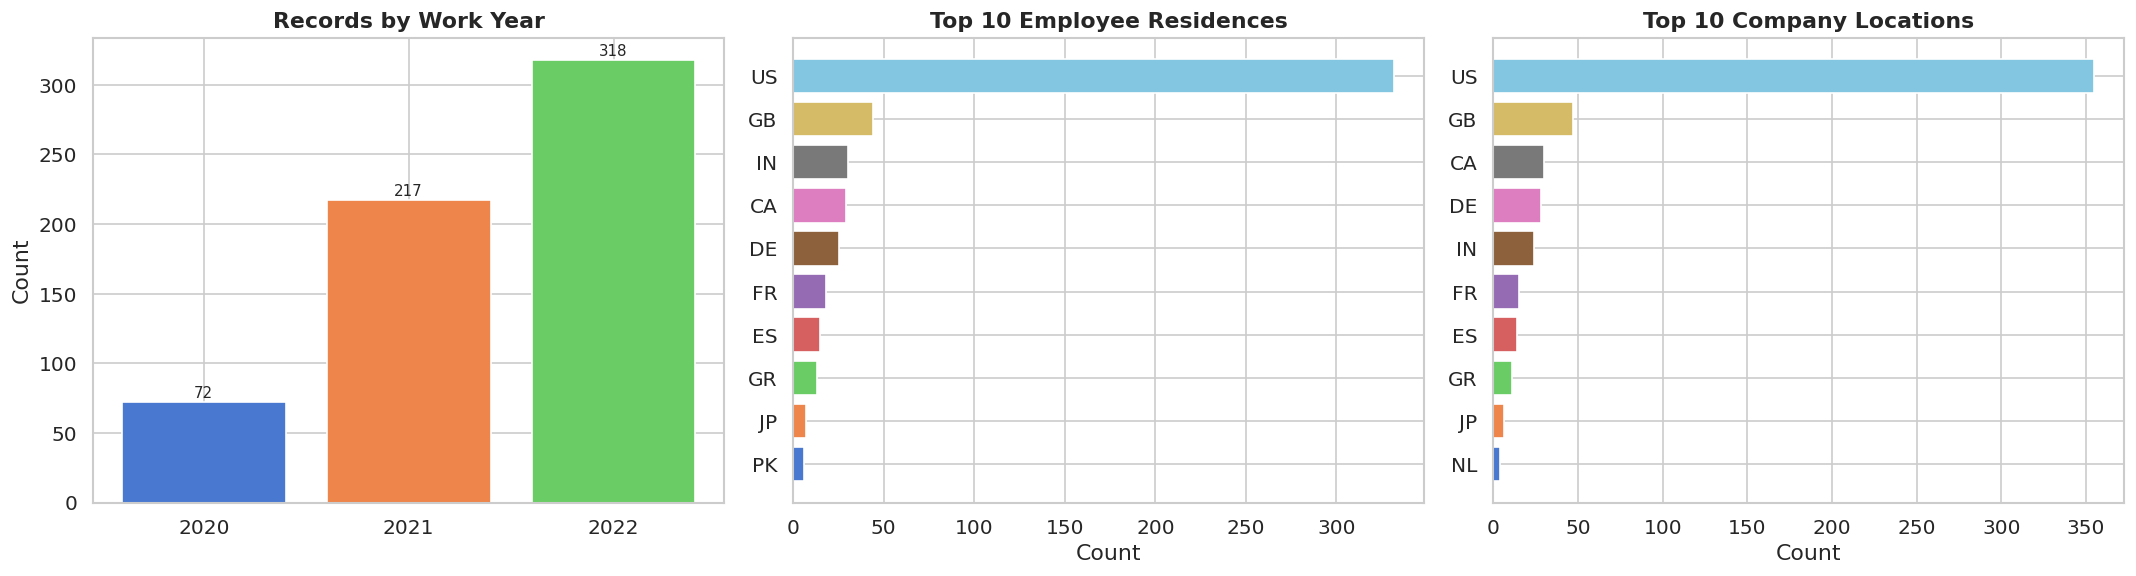

In [13]:
# ── Work Year + Top Employee / Company Locations ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

year_counts = df["work_year"].value_counts().sort_index()
axes[0].bar(year_counts.index.astype(str), year_counts.values,
            color=sns.color_palette("muted", len(year_counts)), edgecolor="white")
for i, (yr, val) in enumerate(year_counts.items()):
    axes[0].text(i, val + 1, str(val), ha="center", va="bottom", fontsize=9)
axes[0].set_title("Records by Work Year", fontweight="bold")
axes[0].set_ylabel("Count")

top_res = df["employee_residence"].value_counts().head(10)
axes[1].barh(top_res.index[::-1], top_res.values[::-1],
             color=sns.color_palette("muted", 10), edgecolor="white")
axes[1].set_title("Top 10 Employee Residences", fontweight="bold")
axes[1].set_xlabel("Count")

top_loc = df["company_location"].value_counts().head(10)
axes[2].barh(top_loc.index[::-1], top_loc.values[::-1],
             color=sns.color_palette("muted", 10), edgecolor="white")
axes[2].set_title("Top 10 Company Locations", fontweight="bold")
axes[2].set_xlabel("Count")

plt.tight_layout()
plt.show()

### `salary` · `salary_currency` · `salary_in_usd` — Salary Columns

| Column | Type | Description |
|--------|------|-------------|
| `salary` | numeric | Gross salary in the **local currency** of the employee |
| `salary_currency` | categorical · nominal | ISO 4217 currency code of `salary` (e.g. `USD`, `EUR`, `GBP`) |
| `salary_in_usd` | numeric · **regression target** | Salary converted to USD using the avg FX rate for that year — used throughout for comparability |


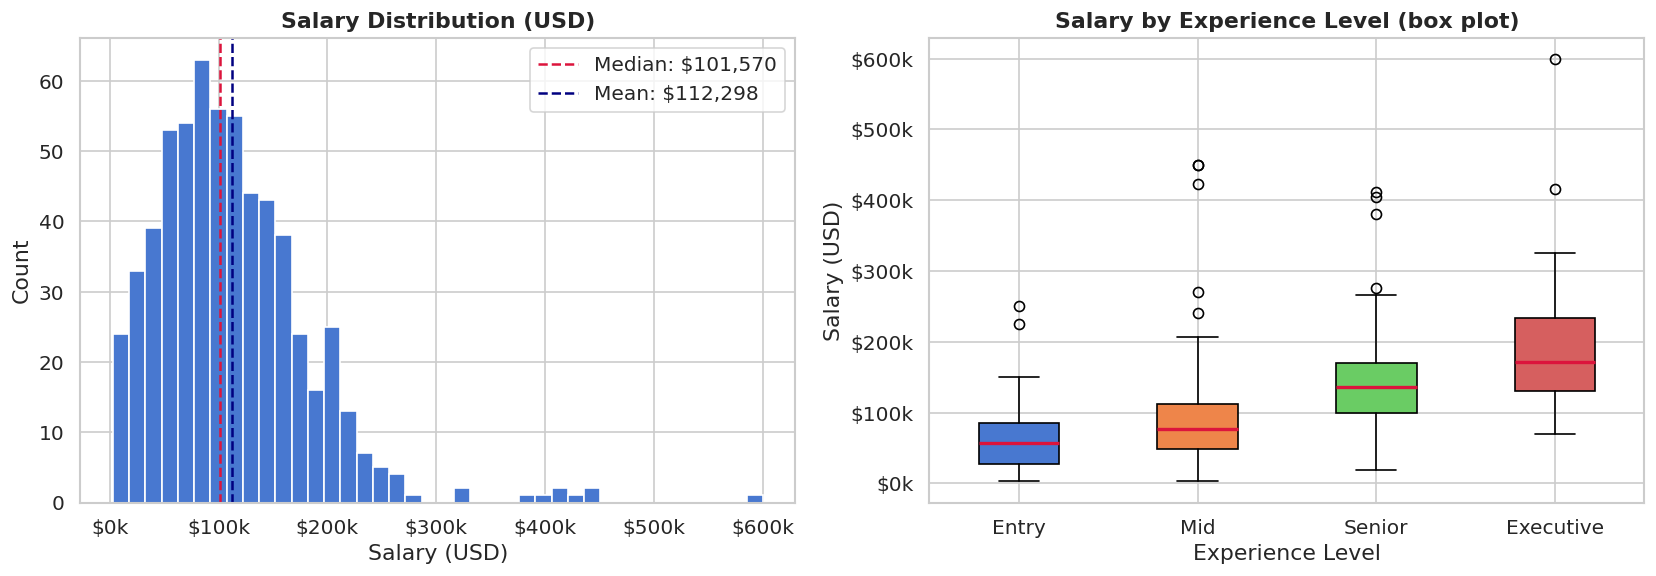

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["salary_in_usd"], bins=40,
             color=sns.color_palette("muted")[0], edgecolor="white")
axes[0].axvline(df["salary_in_usd"].median(), color="crimson", linestyle="--",
                linewidth=1.5, label=f'Median: ${df["salary_in_usd"].median():,.0f}')
axes[0].axvline(df["salary_in_usd"].mean(), color="navy", linestyle="--",
                linewidth=1.5, label=f'Mean: ${df["salary_in_usd"].mean():,.0f}')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[0].set_title("Salary Distribution (USD)", fontweight="bold")
axes[0].set_xlabel("Salary (USD)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Boxplot by experience level
exp_order_full = ["EN", "MI", "SE", "EX"]
data_by_exp = [df[df["experience_level"] == lvl]["salary_in_usd"].values
               for lvl in exp_order_full]
bp = axes[1].boxplot(data_by_exp, patch_artist=True,
                      medianprops={"color": "crimson", "linewidth": 2})
for patch, color in zip(bp["boxes"], sns.color_palette("muted", 4)):
    patch.set_facecolor(color)
axes[1].set_xticklabels(["Entry", "Mid", "Senior", "Executive"])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[1].set_title("Salary by Experience Level (box plot)", fontweight="bold")
axes[1].set_xlabel("Experience Level")
axes[1].set_ylabel("Salary (USD)")

plt.tight_layout()
plt.show()

#### How to read a box plot

A box plot (also called a box-and-whisker plot) compresses an entire distribution into five numbers:

```
         ┌──────────────┐
  ───|───│      │       │───|───   ○  ○
         └──────────────┘
  Min   Q1    Median   Q3   Max  Outliers
 whisker                   whisker
```

| Element | What it represents |
|---------|-------------------|
| **Median line** (inside the box) | Middle value — 50% of records are below, 50% above |
| **Box (IQR)** | Interquartile range — the middle 50% of the data (Q1 to Q3) |
| **Lower whisker** | Extends to the smallest value still within Q1 − 1.5 × IQR |
| **Upper whisker** | Extends to the largest value still within Q3 + 1.5 × IQR |
| **Circles beyond whiskers** | **Outliers** — individual points that fall outside the 1.5 × IQR fence |

This makes box plots one of the most effective tools for spotting outliers at a glance: any point plotted as an individual circle is statistically extreme relative to the rest of the group. Unlike a histogram, box plots also allow **direct side-by-side comparison** of multiple groups (here, experience levels) on the same axis.


#### Data density vs prediction reliability

The model will be most accurate where **training data is densest** — both in terms of experience-level sample size and salary-range concentration. The visualisation below combines both dimensions: violin width shows data density, annotations show sample count, and the overlaid histogram reveals which salary bands are best-represented across experience levels.

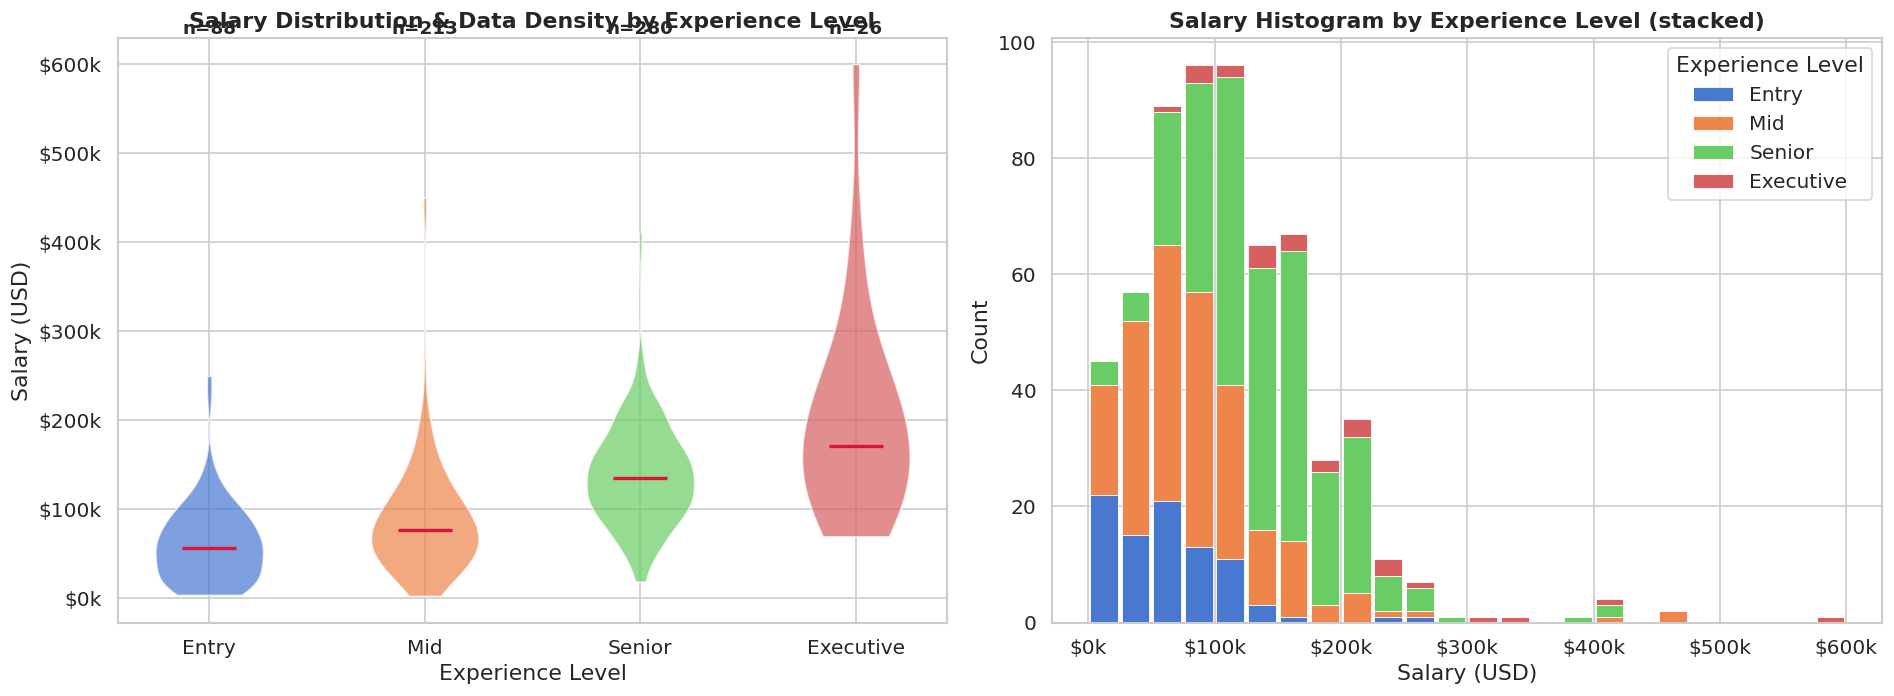

In [15]:
# ── Violin plots + stacked histogram by experience level ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Violin plots per experience level ---
exp_order_violin = ["EN", "MI", "SE", "EX"]
exp_labels_violin = {"EN": "Entry", "MI": "Mid", "SE": "Senior", "EX": "Executive"}
palette_violin = dict(zip(exp_order_violin, sns.color_palette("muted", 4)))

parts = axes[0].violinplot(
    [df[df["experience_level"] == lvl]["salary_in_usd"].values for lvl in exp_order_violin],
    positions=range(len(exp_order_violin)),
    showmedians=True,
    showextrema=False,
)
for i, (pc, lvl) in enumerate(zip(parts["bodies"], exp_order_violin)):
    pc.set_facecolor(palette_violin[lvl])
    pc.set_alpha(0.7)
parts["cmedians"].set_color("crimson")
parts["cmedians"].set_linewidth(2)

# Annotate with sample counts
for i, lvl in enumerate(exp_order_violin):
    n = (df["experience_level"] == lvl).sum()
    axes[0].text(i, df["salary_in_usd"].max() * 1.05, f"n={n}",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")

axes[0].set_xticks(range(len(exp_order_violin)))
axes[0].set_xticklabels([exp_labels_violin[k] for k in exp_order_violin])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[0].set_title("Salary Distribution & Data Density by Experience Level", fontweight="bold")
axes[0].set_ylabel("Salary (USD)")
axes[0].set_xlabel("Experience Level")

# --- Right: Stacked histogram — salary distribution coloured by experience level ---
salary_bins = np.arange(0, df["salary_in_usd"].max() + 25_000, 25_000)
bottom = np.zeros(len(salary_bins) - 1)

for lvl in exp_order_violin:
    subset = df[df["experience_level"] == lvl]["salary_in_usd"]
    counts_hist, _ = np.histogram(subset, bins=salary_bins)
    axes[1].bar(
        salary_bins[:-1] + 12_500,  # centre of each bin
        counts_hist,
        bottom=bottom,
        width=22_000,
        label=exp_labels_violin[lvl],
        color=palette_violin[lvl],
        edgecolor="white",
        linewidth=0.5,
    )
    bottom += counts_hist

axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[1].set_title("Salary Histogram by Experience Level (stacked)", fontweight="bold")
axes[1].set_xlabel("Salary (USD)")
axes[1].set_ylabel("Count")
axes[1].legend(title="Experience Level", loc="upper right")

plt.tight_layout()
plt.show()


#### Findings

**Distribution shape — right skew**
- The histogram is right-skewed: the bulk of salaries cluster between \$60k–\$150k, with a long tail extending to ~\$600k.
- Mean (\$112k) > Median (\$102k) — a \$10k gap that signals right skew. A few very high salaries pull the mean upward without affecting the median.

**Outliers and capping**
- Several records exceed \$400k–\$600k, visible as isolated bars on the far right of the histogram and as circles beyond the box-plot whiskers.
- Outliers appear across all experience levels but are most prominent in Mid and Executive — likely reflecting exceptionally high-paying roles or data entry errors.
- During the cleaning step these extremes are **capped using the IQR method** (Q1 − 1.5×IQR as the lower fence, Q3 + 1.5×IQR as the upper fence). Values beyond the fences are pulled inward to the fence boundary, so no records are lost — the long tail is simply compressed.

**Salary progression by experience**
- There is a clear monotonic increase from Entry → Mid → Senior → Executive, validating `experience_level` as a strong predictor.
- The **IQR (box height) widens** at each level — salary variance grows with seniority. Executives have both the highest median and the most spread.
- Entry-level has the tightest distribution (narrow box), consistent with compressed salary bands for junior roles.
- Senior and Executive levels overlap somewhat in their upper quartiles, suggesting some senior roles are compensated comparably to executive positions.

**Data density and expected model reliability**
- The **\$50k–\$200k salary band** contains the vast majority of training records. The model will have the most evidence — and therefore the lowest error — for predictions in that range.
- **Senior** roles alone account for nearly half the dataset, followed by **Mid-level**. These two groups dominate the dense centre of the salary distribution, giving the model the most peer-group examples to learn from.
- **Executive** roles have very few records (~15) and the widest salary spread — predictions there are essentially under-determined.
- **Entry-level** has a tight distribution but a small sample — the model may overfit to the few patterns available.
- Salaries above ~\$250k are sparsely represented regardless of experience level, and after IQR capping the effective upper bound is even lower. The model should be treated as a rough ballpark outside the dense \$50k–\$200k core.

**Key takeaway**: the model is designed for mid-range data professionals (Mid and Senior roles in the \$50k–\$200k band), where data density is highest and salary distributions are most well-defined. For extreme salary profiles, the prediction range (Q25–Q75) and the LLM narrative's uncertainty disclosure become the primary value — not the point estimate.

## 5 · Salary Range Bucketing

Bin `salary_in_usd` into labelled ranges for categorical analysis and heatmaps.

> **Decision point**: adjust `bin_edges` and `bin_labels` below after reviewing the histogram in Section 4.2.

In [16]:
# ── Salary bin configuration — modify as needed ───────────────────────
bin_edges = [0, 50_000, 100_000, 150_000, 200_000, float("inf")]
bin_labels = ["<$50k", "$50k–$100k", "$100k–$150k", "$150k–$200k", ">$200k"]

df["salary_range"] = pd.cut(
    df["salary_in_usd"],
    bins=bin_edges,
    labels=bin_labels,
    right=False,
)

print("Salary range distribution:")
print(df["salary_range"].value_counts().reindex(bin_labels).to_string())

Salary range distribution:
salary_range
<$50k          102
$50k–$100k     185
$100k–$150k    161
$150k–$200k     95
>$200k          64


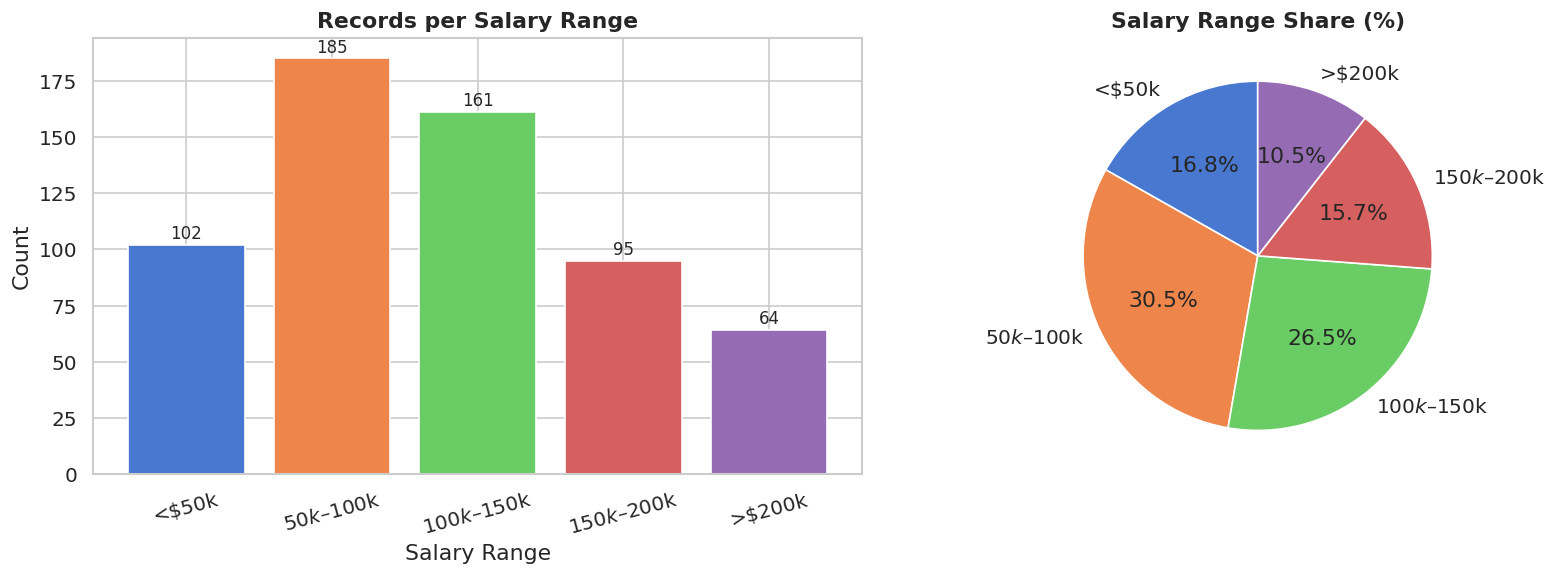

In [17]:
# ── Visualise the buckets ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette("muted", len(bin_labels))
range_counts = df["salary_range"].value_counts().reindex(bin_labels)

bars = axes[0].bar(range_counts.index, range_counts.values, color=palette, edgecolor="white")
for bar, val in zip(bars, range_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, str(val),
                 ha="center", va="bottom", fontsize=10)
axes[0].set_title("Records per Salary Range", fontweight="bold")
axes[0].set_xlabel("Salary Range")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)

axes[1].pie(
    range_counts.values, labels=range_counts.index,
    autopct="%1.1f%%", colors=palette,
    startangle=90, wedgeprops={"edgecolor": "white"}
)
axes[1].set_title("Salary Range Share (%)", fontweight="bold")
plt.tight_layout()
plt.show()

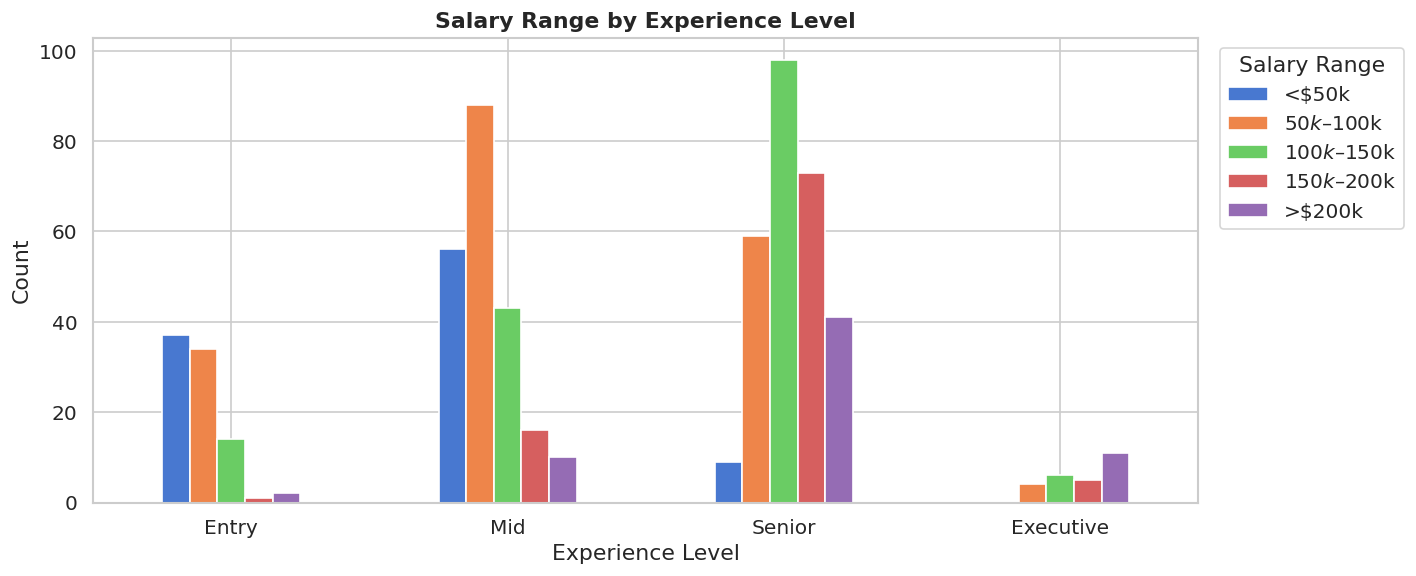

In [18]:
# ── Salary range × Experience Level (grouped bar) ─────────────────────
cross = pd.crosstab(df["experience_level"], df["salary_range"]).reindex(exp_order)
cross.index = ["Entry", "Mid", "Senior", "Executive"]

fig, ax = plt.subplots(figsize=(12, 5))
cross.plot(kind="bar", ax=ax, color=palette, edgecolor="white", rot=0)
ax.set_title("Salary Range by Experience Level", fontweight="bold")
ax.set_xlabel("Experience Level")
ax.set_ylabel("Count")
ax.legend(title="Salary Range", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 6 · Correlation with salary_in_usd

### 6.1 · Overall feature correlation (Pearson)

Pearson correlation measures the **linear relationship** between each feature and `salary_in_usd`. It expects numbers — so categorical columns must first be converted to integers.

#### What is OrdinalEncoder?

`OrdinalEncoder` (from scikit-learn) converts each category to an integer based on the order it appears (or a specified order). For example:

```
experience_level:  EN → 0,  MI → 1,  SE → 2,  EX → 3
company_size:       S → 0,   M → 1,   L → 2
```

This works well when the column has a **true natural order** — the numeric gaps are meaningful (going from 0→1→2→3 reflects a real progression in seniority or size). Pearson then picks up on that monotonic trend correctly.

#### Why high-cardinality columns produce noisy results

For columns like `job_title` (50+ unique values) or `employee_residence` (80+ country codes), `OrdinalEncoder` still assigns integers — but now they are **arbitrary**:

```
job_title:  "AI Scientist" → 0,  "Analytics Engineer" → 1,  "Applied Data Scientist" → 2, ...
```

The assignment is alphabetical (or encounter-order), not meaningful. There is no real reason why "Data Scientist" should be numerically "closer" to "Data Engineer" than to "ML Engineer." The resulting integers look like real data to Pearson, but the gaps between them carry no information.

The correlation coefficient that comes out is essentially **random noise** — it reflects the accident of alphabetical ordering, not any actual salary signal. Including it would make the chart misleading.

> **Rule of thumb**: only run OrdinalEncoder + Pearson on a column if you can write down the ordering yourself and it makes sense. If you can't, the column needs a different analysis method (e.g. groupby mean, ANOVA, or tree-based feature importance after one-hot encoding).

---

**Column selection — why each column was included or excluded:**

| Column | Decision | Reason |
|--------|----------|--------|
| `experience_level` | ✅ Included | Ordinal with a clear natural order (EN < MI < SE < EX) — encoding is meaningful |
| `employment_type` | ✅ Included | Only 4 values; included for completeness, but result should be interpreted cautiously — no true numeric order |
| `remote_ratio` | ✅ Included | Already numeric and ordinal (0, 50, 100) — no encoding distortion |
| `company_size` | ✅ Included | Ordinal with a clear natural order (S < M < L) — encoding is meaningful |
| `work_year` | ✅ Included | Already numeric and ordered in time — no encoding needed |
| `salary` | ❌ Excluded | **Data leakage** — `salary_in_usd` is computed directly from `salary` via FX conversion; correlation would be near 1.0 trivially |
| `salary_currency` | ❌ Excluded | Nominal with no meaningful order; highly correlated with `salary` — no useful signal for prediction |
| `job_title` | ❌ Excluded | High-cardinality nominal (50–90+ unique values) — ordinal encoding assigns arbitrary integers, making Pearson correlation meaningless noise |
| `employee_residence` | ❌ Excluded | High-cardinality nominal (80+ country codes) — same problem as `job_title` |
| `company_location` | ❌ Excluded | High-cardinality nominal (80+ country codes) — same problem as `job_title` |

> This is exploratory only — ordinal encoding of nominal columns is intentionally naive here.


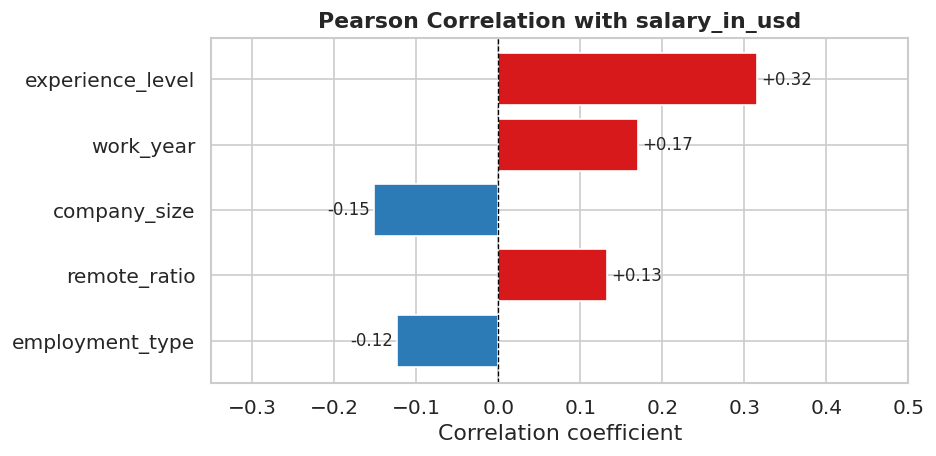

In [19]:
from sklearn.preprocessing import OrdinalEncoder

CATEGORICAL_COLS = ["experience_level", "employment_type", "remote_ratio",
                    "company_size", "work_year"]
NUMERIC_COLS = ["salary_in_usd"]

df_encoded = df[CATEGORICAL_COLS + NUMERIC_COLS].copy()
enc = OrdinalEncoder()
df_encoded[CATEGORICAL_COLS] = enc.fit_transform(df_encoded[CATEGORICAL_COLS])

# Correlation with salary_in_usd only — sorted by absolute value
corr_with_salary = (
    df_encoded.corr(method="pearson")["salary_in_usd"]
    .drop("salary_in_usd")
    .sort_values(key=abs, ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d7191c" if v > 0 else "#2c7bb6" for v in corr_with_salary.values]
bars = ax.barh(corr_with_salary.index, corr_with_salary.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
for bar, val in zip(bars, corr_with_salary.values):
    ax.text(
        val + (0.005 if val >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.2f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=10,
    )
ax.set_title("Pearson Correlation with salary_in_usd", fontweight="bold")
ax.set_xlabel("Correlation coefficient")
ax.set_xlim(-0.35, 0.5)
plt.tight_layout()
plt.show()


#### Findings

> **Note**: correlations here are indicative only — ordinal encoding of nominal columns (e.g. `employment_type`) assigns arbitrary integers, so their values should not be over-interpreted.

| Feature | Correlation | Interpretation |
|---------|-------------|----------------|
| `experience_level` | +0.32 | Strongest predictor — higher seniority → higher salary |
| `work_year` | +0.17 | Salaries have grown year-on-year — recency matters |
| `remote_ratio` | +0.13 | Weak positive — fully-remote roles skew slightly higher |
| `company_size` | −0.15 | Weak negative — due to encoding order (S=0, M=1, L=2); medium companies dominate the dataset |
| `employment_type` | −0.12 | Essentially noise — encoding is arbitrary for a nominal column |

**Key takeaways for feature selection:**
- `experience_level` is the clearest linear signal and should be kept.
- `work_year` is worth including — it captures salary inflation over time.
- `employment_type` and `company_size` show weak/unreliable linear correlations here; their value will be better assessed through tree-based feature importance after encoding.
- All correlations are modest (< 0.35), confirming that salary prediction is a non-linear problem — a tree-based model (e.g. Random Forest, Gradient Boosting) will likely outperform linear regression.


---

## Summary & Decisions

### Observations

**Experience level distribution**
- The dataset is dominated by **Senior** roles, followed by Mid-level. Entry and Executive are significantly less represented.
- No level is sparse enough to drop — all four will be kept as a feature.

**Target column**
- `salary_in_usd` is chosen as the regression target.
- `salary` (local currency) and `salary_currency` are redundant: `salary_in_usd` is already derived from them via FX conversion. Both are excluded from features to prevent data leakage.

**Salary range buckets**
- The current bin edges (\$0 / \$50k / \$100k / \$150k / \$200k / ∞) produce reasonable, populated buckets.
- No bucket is too sparse to be useful — no change needed.

**Feature correlations with `salary_in_usd`** (from Section 6.1)
- `experience_level` (+0.32) — strongest signal; seniority directly drives salary.
- `work_year` (+0.17) — captures salary inflation over time; worth keeping.
- `remote_ratio` (+0.13) — weak positive; fully-remote roles skew slightly higher.
- All correlations are modest (< 0.35) — salary prediction is a non-linear problem.

---

### Decisions

| Decision | Choice |
|----------|--------|
| Target column | `salary_in_usd` ✅ |
| Drop from features | `salary`, `salary_currency` — redundant / data leakage |
| Drop from features | `employee_residence` — largely redundant with `company_location` |
| Salary range bin edges | Keep current: \$0 / \$50k / \$100k / \$150k / \$200k / ∞ |
| `experience_level` | Keep as-is — ordinal, strong signal |
| `work_year` | Keep as-is — numeric, captures salary inflation |
| `remote_ratio` | Keep as-is — already numeric (0 / 50 / 100) |
| `employment_type` | Keep — encode with OrdinalEncoder; weak signal but low cost |
| `company_size` | Keep — ordinal (S < M < L); weak signal but low cost |

---

### Feature engineering required

**`job_title` → `job_family`**

All titles are tech/data roles, so grouping by *function* is the right approach. Create a new `job_family` column with ~5 groups:

| `job_family` | Example titles |
|--------------|---------------|
| `data_science` | Data Scientist, Applied Data Scientist, Staff Data Scientist |
| `data_engineering` | Data Engineer, Analytics Engineer, ETL Developer |
| `ml_ai` | ML Engineer, AI Scientist, Computer Vision Engineer, NLP Engineer |
| `analytics` | Data Analyst, BI Analyst, Business Data Analyst |
| `leadership` | Head of Data, Director of Data Science, Principal Data Scientist |

Encode `job_family` using **target encoding** (mean `salary_in_usd` per group, computed on training data only to avoid leakage).

**`company_location` → `location_region`**

Geography matters — US/UK employers pay significantly more than those in lower-cost countries — but 80+ country codes are too sparse to model individually. Map to pay regions:

| `location_region` | Countries |
|-------------------|-----------|
| `north_america` | US, CA |
| `western_europe` | GB, DE, FR, NL, ES, PT, CH, … |
| `asia_pacific` | IN, JP, AU, SG, … |
| `rest_of_world` | All others |

Since ~80% of records are US-based, also add a binary flag `is_us_company` as a fast baseline signal.
